In [1]:
import pandas as pd
import numpy as np

import sys
from pathlib import Path
PROJECT_ROOT = Path().resolve()
while not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))

from src.labeling import add_returns
from src.volatility import add_close_to_close_volatility

df = pd.read_csv("../data/raw/nifty50.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)

df = add_returns(df)
df = add_close_to_close_volatility(df)

reg = pd.read_csv("../data/processed/hmm_regimes_refit.csv", parse_dates=["Date"])

df = df.merge(reg, on="Date", how="left")

df = df.dropna(subset=["return","hmm_regime"])

In [2]:
dist_stats = df.groupby("hmm_regime")["return"].agg(
    mean="mean",
    std="std",
    skew="skew",
    kurtosis="kurt"
)
#basic distribution stats
dist_stats

,mean,std,skew,kurtosis
hmm_regime,,,,
High,0.000536,0.021406,0.037085,6.833014
Low,-0.000106,0.008145,-0.178042,0.815410
Medium,0.000857,0.008130,-0.049975,0.728107


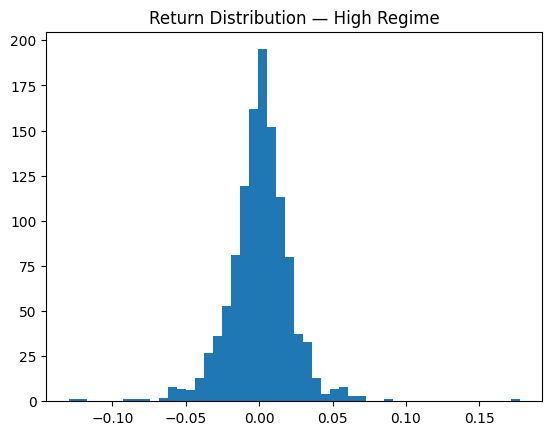

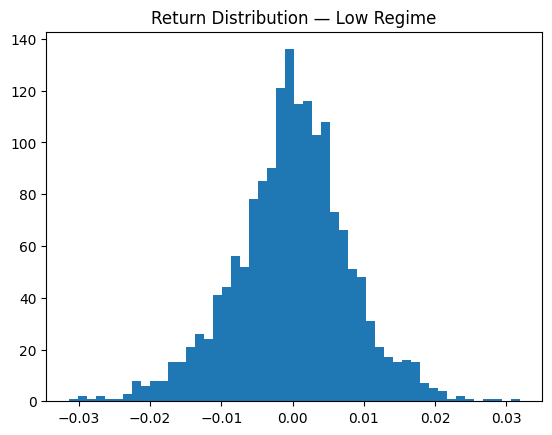

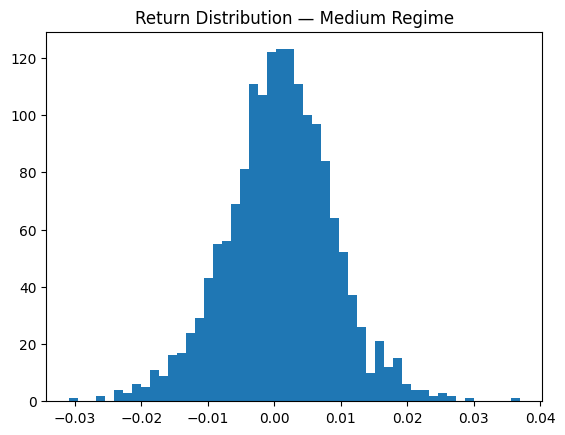

In [3]:
import matplotlib.pyplot as plt
#Visualising Return Distributions
regimes = df["hmm_regime"].unique()

for r in regimes:
    
    subset = df[df["hmm_regime"] == r]
    
    plt.hist(subset["return"], bins=50)
    plt.title(f"Return Distribution — {r} Regime")
    plt.show()

## **Downside vs Upside Tail Risk**

In [5]:
threshold = 2 * df["return"].std()

df["extreme"] = abs(df["return"]) > threshold

extreme_stats = df.groupby("hmm_regime")["extreme"].mean()
#Which regime produces most extreme events?
extreme_stats

hmm_regime
High      0.166809
Low       0.005412
Medium    0.004194
Name: extreme, dtype: float64

## **Downside vs Upside Extremes**

In [6]:
df["extreme_down"] = df["return"] < -threshold
df["extreme_up"] = df["return"] > threshold
#seperating -ve tail risk
tail_stats = df.groupby("hmm_regime")[["extreme_down","extreme_up"]].mean()
#Is the downside tail larger than the upside tail?
tail_stats

,extreme_down,extreme_up
hmm_regime,,
High,0.084688,0.082121
Low,0.003608,0.001804
Medium,0.001797,0.002397


## **Quantile Spread by Regime**

In [9]:
quantiles = df.groupby("hmm_regime")["return"].quantile([0.1,0.5,0.9]).unstack()
quantiles

,0.1,0.5,0.9
hmm_regime,,,
High,-0.023282,0.001036,0.022958
Low,-0.010447,0.000096,0.009695
Medium,-0.009287,0.000992,0.010494


In [10]:
quantiles["width"] = quantiles[0.9] - quantiles[0.1]
quantiles

,0.1,0.5,0.9,width
hmm_regime,,,,
High,-0.023282,0.001036,0.022958,0.046240
Low,-0.010447,0.000096,0.009695,0.020142
Medium,-0.009287,0.000992,0.010494,0.019780


## **Regime Conditioned Value at Risk**

In [11]:
var_stats = df.groupby("hmm_regime")["return"].quantile([0.01,0.05]).unstack()
var_stats

,0.01,0.05
hmm_regime,,
High,-0.058667,-0.033730
Low,-0.022036,-0.014213
Medium,-0.019686,-0.012975
